# 🔺 STL → VTK Converter
> **Simple · Lossless · Full quality**

| Cell | What it does |
|------|--------------|
| 1 | Install |
| 2 | Config — set your paths |
| 3 | Convert STL → VTK |
| 4 | Validate + stats |

**What is preserved**
- All vertex XYZ coordinates (float64, lossless)
- All triangle faces
- Face normals
- Works on binary STL and ASCII STL
- Duplicate vertices are merged cleanly (STL repeats verts per triangle)

## Cell 1 — Install

In [1]:
import os
os.chdir(r"C:\Mai\BME\BioDat Work\2D-3D-Mri-image\New_version\Data")

STL_PATH   = "ImageToStl.com_head_voxels.stl"   # now just the filename
OUTPUT_DIR = r"C:\Mai\BME\BioDat Work\2D-3D-Mri-image\New_version\Data\outputs"

In [2]:
!pip install pyvista numpy matplotlib -q

import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt
import os, time

print(f"pyvista : {pv.__version__}")
print(f"numpy   : {np.__version__}")

pyvista : 0.48.4
numpy   : 2.2.5


## Cell 2 — Config

In [3]:
# USER EDIT
STL_PATH    = '"C:\\Mai\\BME\\BioDat Work\\2D-3D-Mri-image\\New_version\\Data\\ImageToStl.com_head_voxels.stl"'       # path to your input STL
OUTPUT_DIR  = 'outputs/vtk_export'   # output folder
OUT_FORMAT  = 'vtu'    # 'vtu' = modern XML (recommended)  |  'vtk' = legacy
BINARY_OUT  = True     # True = binary (smaller)  |  False = ASCII (readable)
MERGE_VERTS = True     # merge duplicate vertices (recommended: True)

os.makedirs(OUTPUT_DIR, exist_ok=True)
stem     = os.path.splitext(os.path.basename(STL_PATH))[0]
OUT_PATH = os.path.join(OUTPUT_DIR, f"{stem}.{OUT_FORMAT}")

print(f"Input  : {STL_PATH}   exists={os.path.exists(STL_PATH)}")
print(f"Output : {OUT_PATH}")
print(f"Format : {OUT_FORMAT.upper()} ({'binary' if BINARY_OUT else 'ASCII'})")

Input  : "C:\Mai\BME\BioDat Work\2D-3D-Mri-image\New_version\Data\ImageToStl.com_head_voxels.stl"   exists=False
Output : outputs/vtk_export\ImageToStl.com_head_voxels.vtu
Format : VTU (binary)


## Cell 3 — Convert

In [4]:
import os
os.chdir(r"C:\Mai\BME\BioDat Work\2D-3D-Mri-image\New_version\Data")

STL_PATH   = r"ImageToStl.com_head_voxels.stl"   # now just the filename
OUTPUT_DIR = r"C:\Mai\BME\BioDat Work\2D-3D-Mri-image\New_version\Data\outputs"

In [6]:
# Load STL
print("Loading STL...")
t0   = time.time()
mesh = pv.read(STL_PATH)
print(f"  Raw     : {mesh.n_points:,} points  |  {mesh.n_cells:,} triangles")
print(f"  Bounds X: [{mesh.bounds[0]:.3f}, {mesh.bounds[1]:.3f}]")
print(f"  Bounds Y: [{mesh.bounds[2]:.3f}, {mesh.bounds[3]:.3f}]")
print(f"  Bounds Z: [{mesh.bounds[4]:.3f}, {mesh.bounds[5]:.3f}]")

# Merge duplicate vertices
if MERGE_VERTS:
    print("\nMerging duplicate vertices...")
    mesh = mesh.clean()
    print(f"  After   : {mesh.n_points:,} points  |  {mesh.n_cells:,} triangles")

# Compute normals
print("\nComputing normals...")
mesh = mesh.compute_normals(
    cell_normals        = True,
    point_normals       = True,
    auto_orient_normals = True,
    consistent_normals  = True,
)

# Triangle area per cell
print("Computing cell areas...")
mesh = mesh.compute_cell_sizes(area=True, length=False, volume=False)

# Cast PolyData → UnstructuredGrid so .vtu is valid
# STL loads as PolyData (surface only). .vtu requires UnstructuredGrid.
# cast_to_unstructured_grid() promotes every triangle to a VTK_TRIANGLE cell
# — geometry and all data arrays are preserved exactly.
print("\nCasting PolyData → UnstructuredGrid...")
mesh = mesh.cast_to_unstructured_grid()
print(f"  Type    : {type(mesh).__name__}")
print(f"  Points  : {mesh.n_points:,}")
print(f"  Cells   : {mesh.n_cells:,}")

# Save as .vtu
print(f"\nSaving to {OUT_PATH} ...")
mesh.save(OUT_PATH, binary=BINARY_OUT)

fsize_mb = os.path.getsize(OUT_PATH) / 1e6
print(f"Done in {time.time()-t0:.2f}s  |  {fsize_mb:.1f} MB")
print(f"  Point arrays : {list(mesh.point_data.keys())}")
print(f"  Cell  arrays : {list(mesh.cell_data.keys())}")

Loading STL...
  Raw     : 405,210 points  |  816,040 triangles
  Bounds X: [-0.500, 172.500]
  Bounds Y: [-0.500, 253.500]
  Bounds Z: [-0.500, 226.500]

Merging duplicate vertices...
  After   : 405,210 points  |  816,040 triangles

Computing normals...
Computing cell areas...

Casting PolyData → UnstructuredGrid...
  Type    : UnstructuredGrid
  Points  : 405,210
  Cells   : 816,040

Saving to outputs/vtk_export\ImageToStl.com_head_voxels.vtu ...
Done in 1.59s  |  9.7 MB
  Point arrays : ['Normals']
  Cell  arrays : ['Area', 'Normals']


## Cell 4 — Validate + Stats

Load-back validation...
  Points    : 405,210  OK
  Triangles : 816,040  OK
  Max coord error : 0.00e+00 mm  PASS

Mesh stats:
  Surface area : 298,933.76 mm²
  Volume       : 0.00 mm³  (0.00 cm³)
  Triangle area — min: 0.2165  mean: 0.3663  max: 0.6495 mm²


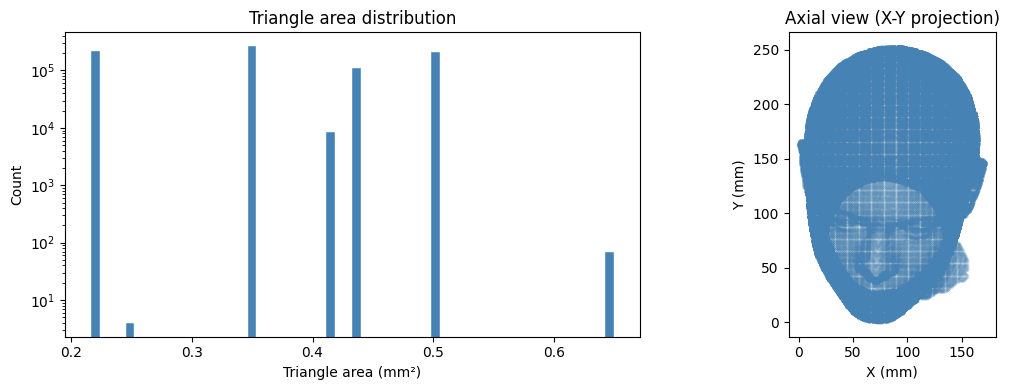


Stats chart: C:\Mai\BME\BioDat Work\2D-3D-Mri-image\New_version\Data\outputs\ImageToStl.com_head_voxels_stats.png

OUTPUT FILES:
  ImageToStl.com_head_voxels_stats.png     0.1 MB
  vtk_export                               0.0 MB

Ready for: ParaView, 3D Slicer, SimpleITK, registration pipeline


In [25]:
# Load-back check
print("Load-back validation...")
check = pv.read(OUT_PATH)

assert check.n_points == mesh.n_points, "Point count mismatch!"
assert check.n_cells  == mesh.n_cells,  "Cell count mismatch!"

max_err = np.max(np.abs(check.points - mesh.points))
print(f"  Points    : {check.n_points:,}  OK")
print(f"  Triangles : {check.n_cells:,}  OK")
print(f"  Max coord error : {max_err:.2e} mm  {'PASS' if max_err < 1e-6 else 'WARN'}")

# Surface stats
total_area = float(np.sum(mesh.cell_data['Area']))
vol        = abs(mesh.volume)
areas      = mesh.cell_data['Area']
print(f"\nMesh stats:")
print(f"  Surface area : {total_area:,.2f} mm²")
print(f"  Volume       : {vol:,.2f} mm³  ({vol/1000:.2f} cm³)")
print(f"  Triangle area — min: {areas.min():.4f}  mean: {areas.mean():.4f}  max: {areas.max():.4f} mm²")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Triangle area histogram
axes[0].hist(areas, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Triangle area (mm²)')
axes[0].set_ylabel('Count')
axes[0].set_title('Triangle area distribution')
axes[0].set_yscale('log')

# Axial projection
pts = mesh.points
axes[1].scatter(pts[:, 0], pts[:, 1], s=0.05, c='steelblue', alpha=0.3, rasterized=True)
axes[1].set_aspect('equal')
axes[1].set_xlabel('X (mm)')
axes[1].set_ylabel('Y (mm)')
axes[1].set_title('Axial view (X-Y projection)')

plt.tight_layout()
chart_path = os.path.join(OUTPUT_DIR, f"{stem}_stats.png")
plt.savefig(chart_path, dpi=120)
plt.show()
print(f"\nStats chart: {chart_path}")

# File list
print("\n" + "="*50)
print("OUTPUT FILES:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    fsize = os.path.getsize(fpath) / 1e6
    print(f"  {fname:<40} {fsize:.1f} MB")
print("="*50)
print("\nReady for: ParaView, 3D Slicer, SimpleITK, registration pipeline")